In [35]:
from data_preparation import data_prep
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, auc, roc_curve, roc_auc_score
from sklearn.feature_selection import RFECV
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

First we load the preprocessed, set a random state and print the distribution of IsBadBuy.

In [36]:
df, numerical_columns, categorical_columns = data_prep()
random_state = 42

To be able to perform the regression modelling we need to do some additional preprocessing as One-hot encoding for categorical variables and scaling for numerical ones.

In [37]:
# One-hot encode categorical variables
df = pd.get_dummies(df, columns=categorical_columns, drop_first=True)

# Split into train/test
X = df.drop(columns=['IsBadBuy'])
y = df['IsBadBuy'].astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=random_state, stratify=y)

# Scale the numerical columns
scaler = StandardScaler()
X_train[numerical_columns] = scaler.fit_transform(X_train[numerical_columns])
X_test[numerical_columns] = scaler.transform(X_test[numerical_columns])

Next we can perform the Logistic Regression and the Grid search. As the response variable IsBadBuy is imbalanced we use stratification and class_weights = 'balanced'

In [38]:
# Logistic Regression
base_lr = LogisticRegression(max_iter=2000, random_state=random_state, solver='liblinear', class_weight='balanced')

In [39]:
param_grid  = {'C': [pow(10, x) for x in range(-6, 4)]}

cv10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=random_state)

cv = GridSearchCV(param_grid=param_grid, estimator=base_lr, cv=cv10, n_jobs=-1, scoring='accuracy', refit=True)
cv.fit(X_train, y_train)

,estimator,LogisticRegre...r='liblinear')
,param_grid,"{'C': [1e-06, 1e-05, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [40]:
# Results
print("Best params:", cv.best_params_)
print("Train accuracy:", cv.score(X_train, y_train))
print("Test accuracy :", cv.score(X_test,  y_test))
print("")
y_pred = cv.predict(X_test)
print(classification_report(y_test, y_pred))

Best params: {'C': 1000}
Train accuracy: 0.6421185169309901
Test accuracy : 0.6415139826422372

              precision    recall  f1-score   support

           0       0.93      0.64      0.76      3611
           1       0.22      0.67      0.33       537

    accuracy                           0.64      4148
   macro avg       0.57      0.65      0.54      4148
weighted avg       0.84      0.64      0.70      4148



In [41]:
# Used features
print(list(X_train.columns))

['VehOdo', 'MMRAcquisitionAuctionAveragePrice', 'MMRAcquisitionAuctionCleanPrice', 'MMRAcquisitionRetailAveragePrice', 'MMRAcquisitionRetailCleanPrice', 'MMRCurrentAuctionAveragePrice', 'MMRCurrentAuctionCleanPrice', 'MMRCurrentRetailAveragePrice', 'MMRCurrentRetailCleanPrice', 'VehBCost', 'WarrantyCost', 'PurchaseMonth_2', 'PurchaseMonth_3', 'PurchaseMonth_4', 'PurchaseMonth_5', 'PurchaseMonth_6', 'PurchaseMonth_7', 'PurchaseMonth_8', 'PurchaseMonth_9', 'PurchaseMonth_10', 'PurchaseMonth_11', 'PurchaseMonth_12', 'PurchaseYear_2010', 'Auction_MANHEIM', 'Auction_OTHER', 'VehYear_2002', 'VehYear_2003', 'VehYear_2004', 'VehYear_2005', 'VehYear_2006', 'VehYear_2007', 'VehYear_2008', 'VehYear_2009', 'VehYear_2010', 'Make_BUICK', 'Make_CADILLAC', 'Make_CHEVROLET', 'Make_CHRYSLER', 'Make_DODGE', 'Make_FORD', 'Make_GMC', 'Make_HONDA', 'Make_HYUNDAI', 'Make_INFINITI', 'Make_ISUZU', 'Make_JEEP', 'Make_KIA', 'Make_LEXUS', 'Make_LINCOLN', 'Make_MAZDA', 'Make_MERCURY', 'Make_MINI', 'Make_MITSUBISHI

In [42]:
# The most important variables in the model (according to the absolute value of the coefficients)
coefs = pd.Series(np.abs(cv.best_estimator_.coef_[0]), index=X_train.columns)
top5 = coefs.sort_values(ascending=False).head(5)
print("Most influential variables: ")
print(top5)

Most influential variables: 
Make_VOLVO             7.319250
VNST_ID                6.544607
VNST_NY                5.358450
Transmission_Manual    4.594610
VehYear_2010           3.817130
dtype: float64


In [43]:
# Characteristics of cars most likely to be 'kicks' (variables with the highest coefficients)
coefs = pd.Series(cv.best_estimator_.coef_[0], index=X_train.columns)
top5 = coefs.sort_values(ascending=False).head(5)
print("Characteristics of cars most likely to be 'kicks'")
print(top5)

Characteristics of cars most likely to be 'kicks'
Make_LEXUS                       2.939579
VNST_OH                          1.253247
MMRCurrentAuctionAveragePrice    1.230888
Make_INFINITI                    0.732026
VNST_PA                          0.561737
dtype: float64


Next we perform Recursive Feature Elimination to reduce the number of features. Here we use a sparser solver.

In [44]:
rfe_est = LogisticRegression(max_iter=5000, random_state=random_state, C = 0.1, solver='saga', penalty = 'l1')

In [45]:
rfe = RFECV(estimator = rfe_est, step = 5, cv=cv10, scoring='accuracy', n_jobs=-1)
rfe.fit(X_train, y_train)

print("Original feature set", X_train.shape[1])
print("Number of features after elimination", rfe.n_features_)

Original feature set 125
Number of features after elimination 55


In [46]:
# selected features
sel_mask = rfe.support_
sel_cols = X_train.columns[sel_mask]

X_train_sel = X_train[sel_cols]
X_test_sel  = X_test[sel_cols]

print("Selected Features", list(sel_cols))

Selected Features ['VehOdo', 'MMRAcquisitionAuctionAveragePrice', 'MMRAcquisitionRetailAveragePrice', 'MMRAcquisitionRetailCleanPrice', 'MMRCurrentAuctionAveragePrice', 'MMRCurrentRetailAveragePrice', 'MMRCurrentRetailCleanPrice', 'VehBCost', 'WarrantyCost', 'PurchaseMonth_3', 'PurchaseMonth_4', 'PurchaseMonth_5', 'PurchaseMonth_6', 'PurchaseMonth_7', 'PurchaseMonth_9', 'PurchaseMonth_11', 'PurchaseMonth_12', 'PurchaseYear_2010', 'Auction_MANHEIM', 'VehYear_2002', 'VehYear_2003', 'VehYear_2005', 'VehYear_2006', 'VehYear_2007', 'VehYear_2008', 'VehYear_2009', 'Make_CHEVROLET', 'Make_CHRYSLER', 'Make_DODGE', 'Make_GMC', 'Make_NISSAN', 'Make_PONTIAC', 'Make_SUZUKI', 'Transmission_MANUAL', 'WheelType_Covers', 'WheelType_Special', 'Size_CROSSOVER', 'Size_LARGE', 'Size_LARGE SUV', 'Size_MEDIUM', 'Size_MEDIUM SUV', 'Size_SMALL SUV', 'Size_SMALL TRUCK', 'Size_SPECIALTY', 'Size_VAN', 'VNST_AZ', 'VNST_CA', 'VNST_GA', 'VNST_NC', 'VNST_OK', 'VNST_PA', 'VNST_SC', 'VNST_TN', 'VNST_TX', 'VNST_VA']


Next we tune the new model with grid search to find the best parameter setting.

In [47]:
# grid search CV
rfe_cv = GridSearchCV(param_grid=param_grid, estimator=base_lr, cv=cv10, n_jobs=-1, scoring = 'accuracy', refit = True)
rfe_cv.fit(X_train_sel, y_train)

,estimator,LogisticRegre...r='liblinear')
,param_grid,"{'C': [1e-06, 1e-05, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [48]:
# Results
print("Train accuracy:", rfe_cv.score(X_train_sel, y_train))
print("Test accuracy:", rfe_cv.score(X_test_sel, y_test))
print("Best params (reduced set):", rfe_cv.best_params_)
print("")
y_pred = rfe_cv.predict(X_test_sel)
print(classification_report(y_test, y_pred))

Train accuracy: 0.6424935705100728
Test accuracy: 0.6424783027965284
Best params (reduced set): {'C': 0.001}

              precision    recall  f1-score   support

           0       0.92      0.64      0.76      3611
           1       0.21      0.63      0.31       537

    accuracy                           0.64      4148
   macro avg       0.56      0.64      0.54      4148
weighted avg       0.83      0.64      0.70      4148



In [49]:
# Top five variables of the reduced model
coefs = pd.Series(
    np.abs(rfe_cv.best_estimator_.coef_[0]),
    index=sel_cols
).sort_values(ascending=False)

top5 = coefs.head(5)
print("Top-5 features of the reduced model:")
print(top5)

Top-5 features of the reduced model:
WheelType_Covers     0.503760
PurchaseYear_2010    0.212952
Size_LARGE           0.170297
VehBCost             0.157070
Make_CHEVROLET       0.155708
dtype: float64


Create an ROC curve for both regression models 

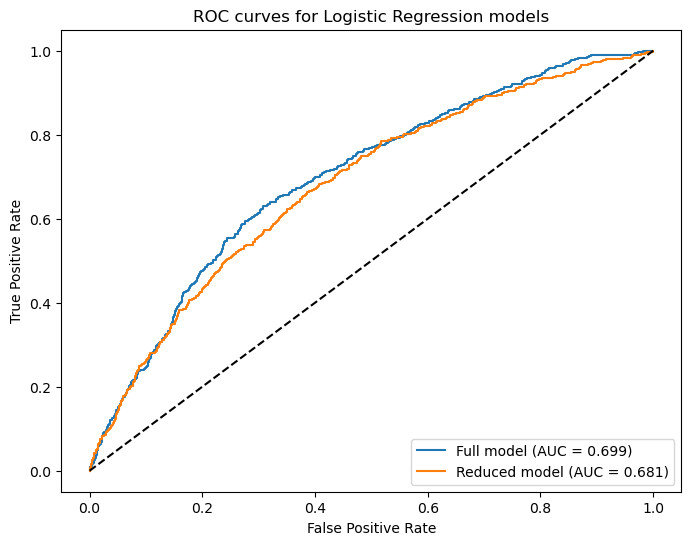

In [50]:
# ROC for full model
y_proba_full = cv.best_estimator_.predict_proba(X_test)[:, 1]
fpr_full, tpr_full, _ = roc_curve(y_test, y_proba_full)
roc_auc_full = auc(fpr_full, tpr_full)

# ROC for reduced model
y_proba_reduced = rfe_cv.best_estimator_.predict_proba(X_test_sel)[:, 1]
fpr_red, tpr_red, _ = roc_curve(y_test, y_proba_reduced)
roc_auc_red = auc(fpr_red, tpr_red)

# Plot
plt.figure(figsize=(8,6))
plt.plot(fpr_full, tpr_full, label=f'Full model (AUC = {roc_auc_full:.3f})')
plt.plot(fpr_red, tpr_red, label=f'Reduced model (AUC = {roc_auc_red:.3f})')
plt.plot([0,1],[0,1],'k--')  # diagonal
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curves for Logistic Regression models')
plt.legend(loc='lower right')
plt.savefig("roc_curve.png", dpi=300, bbox_inches='tight')
plt.show()